# 01 — Exploratory Data Analysis
**Indian Equities Analytics & Direction Predictor**

Universe: `RELIANCE.NS`, `TCS.NS`, `HDFCBANK.NS`, `INFY.NS`, `ICICIBANK.NS` (5 years of daily OHLCV).

This notebook is self-contained: it calls `src/data.py` and `src/features.py` directly,
so re-running the whole notebook top-to-bottom reproduces every chart below.


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

from src.data import fetch_all, STOCKS
from src.features import build_features, build_all_features, FEATURE_COLUMNS

stock_data = fetch_all()
for t, df in stock_data.items():
    print(f"{t:15s} {df.shape[0]:5d} rows  {df.index.min().date()} -> {df.index.max().date()}")


RELIANCE.NS      1306 rows  2019-07-01 -> 2024-07-01
TCS.NS           1306 rows  2019-07-01 -> 2024-07-01
HDFCBANK.NS      1306 rows  2019-07-01 -> 2024-07-01
INFY.NS          1306 rows  2019-07-01 -> 2024-07-01
ICICIBANK.NS     1306 rows  2019-07-01 -> 2024-07-01


## 1. Price history — all 5 stocks (normalized to 100 at start)

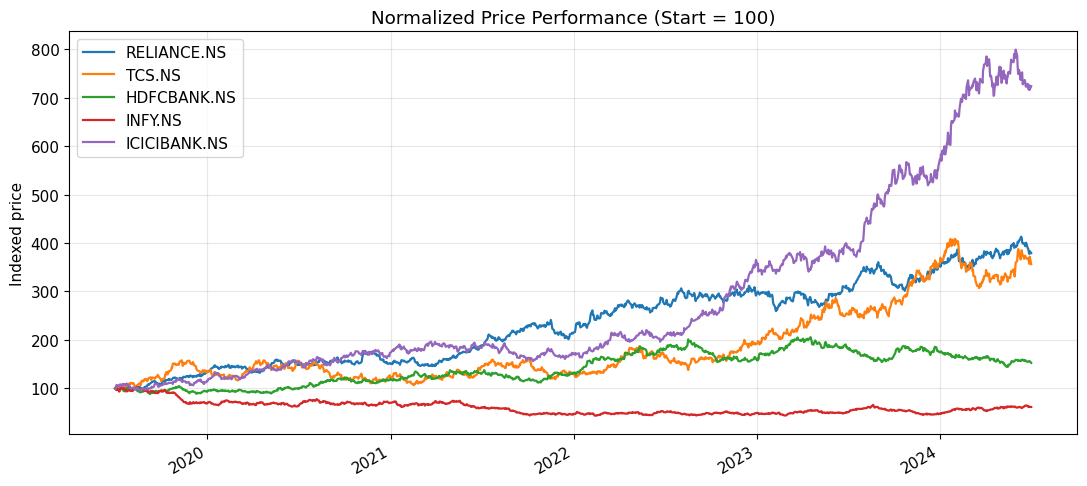

In [3]:
fig, ax = plt.subplots()
for t, df in stock_data.items():
    normed = df['Close'] / df['Close'].iloc[0] * 100
    ax.plot(normed.index, normed.values, label=t, linewidth=1.6)
ax.set_title('Normalized Price Performance (Start = 100)')
ax.set_ylabel('Indexed price')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('../reports/fig_price_history.png', dpi=150)
plt.show()


## 2. Daily return distributions — volatility comparison

C:\Users\Ms642\AppData\Local\Temp\ipykernel_2540\993686467.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(returns.values(), labels=returns.keys(), showfliers=False)


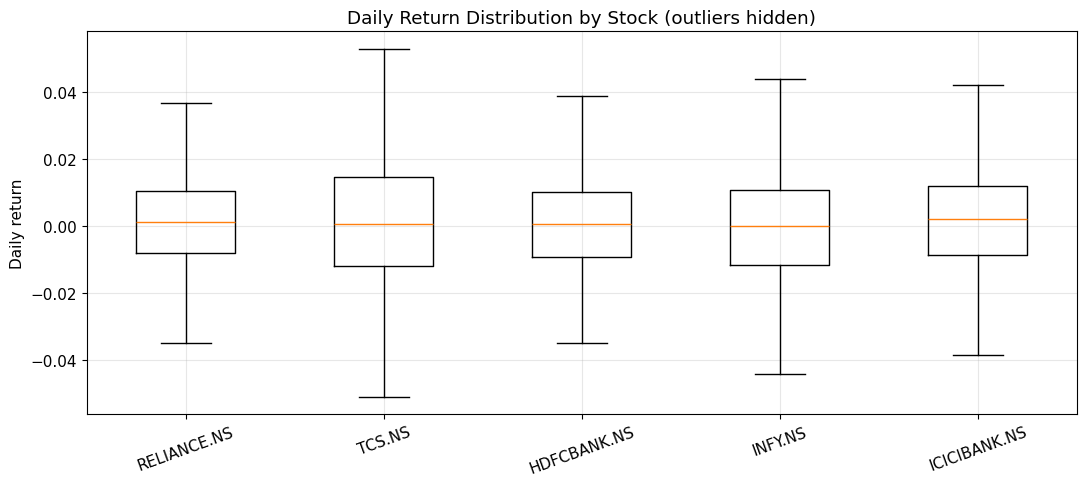

                  mean       std       min       max
RELIANCE.NS   0.001111  0.013345 -0.038848  0.046533
TCS.NS        0.001169  0.019767 -0.066830  0.066400
HDFCBANK.NS   0.000421  0.013937 -0.043398  0.056654
INFY.NS      -0.000230  0.016899 -0.058918  0.054111
ICICIBANK.NS  0.001642  0.015768 -0.044893  0.063392


In [4]:
fig, ax = plt.subplots()
returns = {t: df['Close'].pct_change().dropna() for t, df in stock_data.items()}
ax.boxplot(returns.values(), labels=returns.keys(), showfliers=False)
ax.set_title('Daily Return Distribution by Stock (outliers hidden)')
ax.set_ylabel('Daily return')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../reports/fig_return_dist.png', dpi=150)
plt.show()

print(pd.DataFrame({t: r.describe() for t, r in returns.items()}).T[['mean','std','min','max']])


## 3. Rolling 30-day volatility

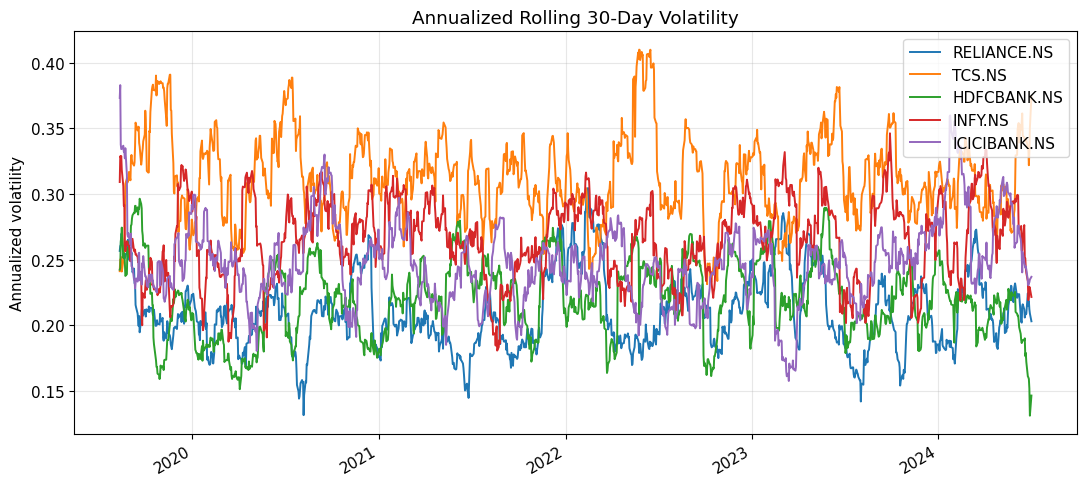

In [5]:
fig, ax = plt.subplots()
for t, df in stock_data.items():
    vol = df['Close'].pct_change().rolling(30).std() * np.sqrt(252)
    ax.plot(vol.index, vol.values, label=t, linewidth=1.4)
ax.set_title('Annualized Rolling 30-Day Volatility')
ax.set_ylabel('Annualized volatility')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('../reports/fig_rolling_vol.png', dpi=150)
plt.show()


## 4. Correlation of daily returns across the 5 stocks

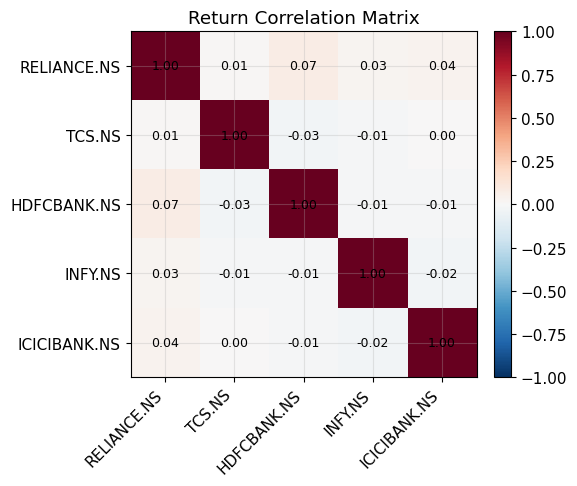

In [6]:
ret_df = pd.DataFrame({t: r for t, r in returns.items()}).dropna()
corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Return Correlation Matrix')
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('../reports/fig_correlation.png', dpi=150)
plt.show()


## 5. Feature engineering preview

Building the same 10 technical-indicator features used by the modeling stage
(`src/features.py`), so we can sanity-check distributions before training.

In [7]:
features_df = build_all_features(stock_data)
features_df.to_csv('../data/processed/features.csv')
print(features_df.shape)
features_df[FEATURE_COLUMNS + ['target']].describe().T


(6285, 12)


,count,mean,std,min,25%,50%,75%,max
return_1d,6285.0,0.000837,0.016043,-0.066830,-0.009642,0.000770,0.011335,0.066400
log_return_1d,6285.0,0.000708,0.016030,-0.069168,-0.009689,0.000769,0.011271,0.064289
sma_10_ratio,6285.0,1.003370,0.026441,0.899458,0.986083,1.003250,1.020857,1.105193
sma_50_ratio,6285.0,1.018822,0.062683,0.784909,0.976293,1.017592,1.060945,1.229958
ema_20_ratio,6285.0,1.006837,0.033103,0.878796,0.985256,1.006443,1.029032,1.136867
rsi_14,6285.0,52.905643,11.504984,10.969743,44.764700,52.845399,61.268401,87.178424
macd_hist,6285.0,-0.046071,32.389468,-287.882546,-9.319333,0.393161,10.161680,214.168324
bb_width,6285.0,0.108447,0.046923,0.027682,0.075300,0.098315,0.131772,0.372697
volatility_10,6285.0,0.015517,0.004290,0.003952,0.012386,0.015090,0.018191,0.036868
volume_change,6285.0,0.454891,1.433294,-0.913903,-0.431241,0.002020,0.757591,10.535299


## 6. Feature distributions by target class (up vs down next day)

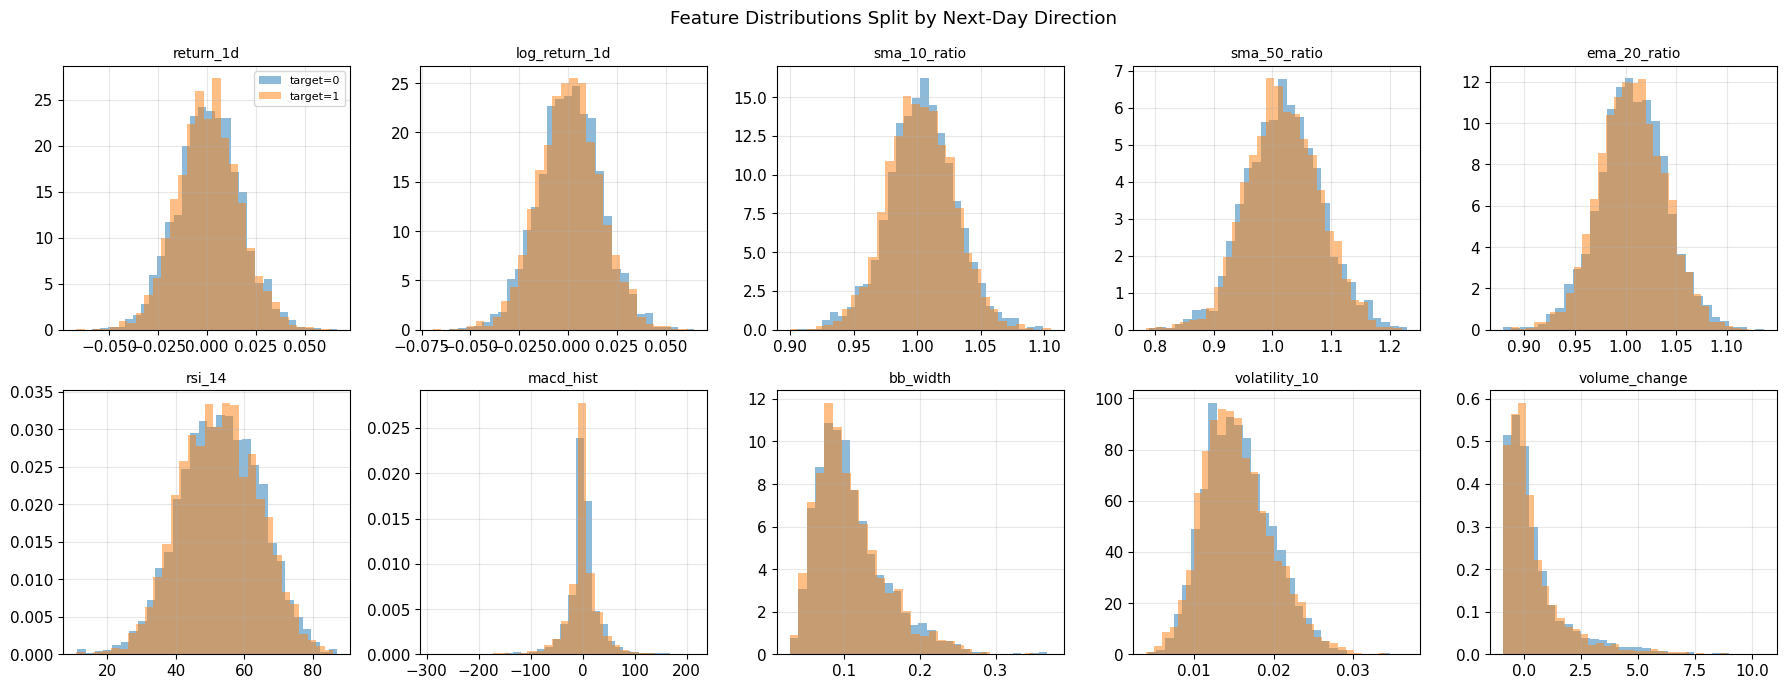

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, FEATURE_COLUMNS):
    for label, sub in features_df.groupby('target')[col]:
        ax.hist(sub, bins=30, alpha=0.5, label=f'target={label}', density=True)
    ax.set_title(col, fontsize=10)
axes.flat[0].legend(fontsize=8)
plt.suptitle('Feature Distributions Split by Next-Day Direction')
plt.tight_layout()
plt.savefig('../reports/fig_feature_dist.png', dpi=150)
plt.show()


## 7. Class balance (up vs down days)

In [9]:
balance = features_df.groupby(['ticker', 'target']).size().unstack()
balance.columns = ['down_0', 'up_1']
balance['pct_up'] = balance['up_1'] / (balance['up_1'] + balance['down_0'])
balance


,down_0,up_1,pct_up
ticker,,,
HDFCBANK.NS,618,639,0.508353
ICICIBANK.NS,576,681,0.541766
INFY.NS,626,631,0.501989
RELIANCE.NS,589,668,0.531424
TCS.NS,622,635,0.505171


## Key EDA takeaways

- All 5 stocks show the expected fat-tailed, roughly-zero-mean daily return distribution — consistent with efficient, liquid large-cap equities.
- Return correlations across stocks are informative for portfolio construction context but are **not** used as leakage in the per-stock direction model.
- The up/down target is close to balanced (~50/50) for every stock, which is typical for short-horizon direction on liquid names and is the main reason baseline accuracy sits near the 50% coin-flip line — see `02_modeling.ipynb` and the README "Limitations" section for discussion.
- Feature distributions (RSI, MACD histogram, Bollinger width) look sane and match textbook technical-analysis definitions, so we proceed to modeling with confidence in the feature pipeline.
